In [1]:

import os, warnings
os.makedirs('charts', exist_ok=True)
os.makedirs('data',   exist_ok=True)
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')
print('Libraries imported')

Libraries imported


---
# TASK 1 — Data Loading, Merging & Exploratory Analysis


In [2]:
TRANSACTION_PATH = 'train_transaction.csv'
IDENTITY_PATH    = 'train_identity.csv'

df_trans = pd.read_csv(TRANSACTION_PATH)
df_ident = pd.read_csv(IDENTITY_PATH)
print(f'Transactions : {df_trans.shape}  |  Identity : {df_ident.shape}')

Transactions : (590540, 394)  |  Identity : (144233, 41)


In [3]:

df = pd.merge(df_trans, df_ident, on='TransactionID', how='left')
print(f'Merged shape : {df.shape}')

print('\nData types:')
print(df.dtypes.value_counts())

key_cols = [c for c in ['TransactionID','isFraud','TransactionDT','TransactionAmt',
                         'ProductCD','card4','card6','P_emaildomain'] if c in df.columns]
df[key_cols].head(10)

Merged shape : (590540, 434)

Data types:
float64    399
str         31
int64        4
Name: count, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card4,card6,P_emaildomain
0,2987000,0,86400,68.5,W,discover,credit,NaN
1,2987001,0,86401,29.0,W,mastercard,credit,gmail.com
2,2987002,0,86469,59.0,W,visa,debit,outlook.com
3,2987003,0,86499,50.0,W,mastercard,debit,yahoo.com
4,2987004,0,86506,50.0,H,mastercard,credit,gmail.com
5,2987005,0,86510,49.0,W,visa,debit,gmail.com
6,2987006,0,86522,159.0,W,visa,debit,yahoo.com
7,2987007,0,86529,422.5,W,visa,debit,mail.com
8,2987008,0,86535,15.0,H,visa,debit,anonymous.com
9,2987009,0,86536,117.0,W,mastercard,debit,yahoo.com


Not Fraud: 569,877 (96.50%)
Fraud    : 20,663 (3.50%)
Imbalance ratio: 27.6:1


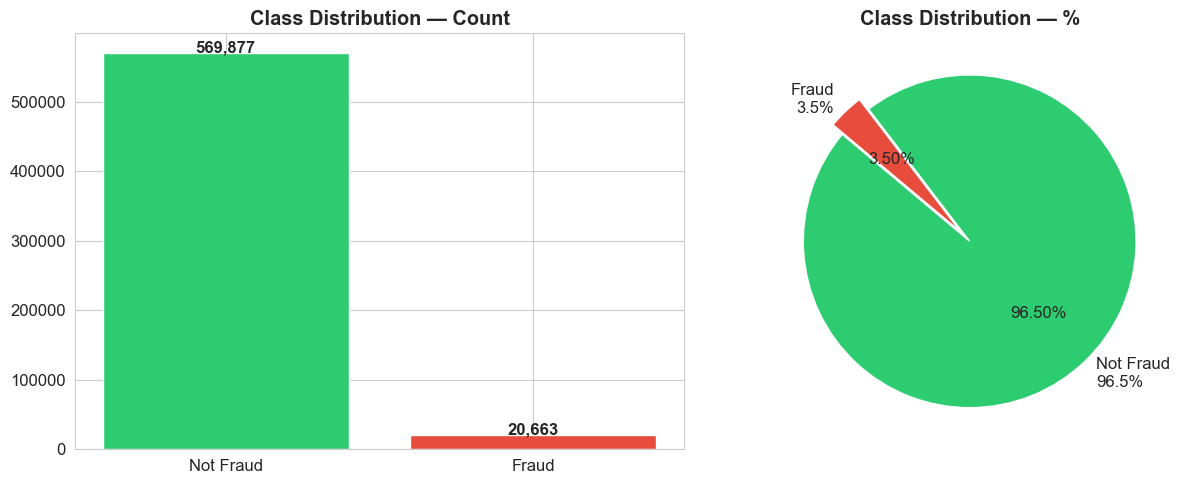

In [4]:

fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True)*100
print(f"Not Fraud: {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud    : {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1")

fig, axes = plt.subplots(1,2,figsize=(13,5))
bars = axes[0].bar(['Not Fraud','Fraud'], fraud_counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
for b,v in zip(bars,fraud_counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[1].pie(fraud_counts.values, labels=[f'Not Fraud\n{fraud_pct[0]:.1f}%',f'Fraud\n{fraud_pct[1]:.1f}%'],
            colors=['#2ecc71','#e74c3c'], explode=(0,0.08), autopct='%1.2f%%', startangle=140)
axes[1].set_title('Class Distribution — %', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

Columns with missing: 414  |  >50%: 214


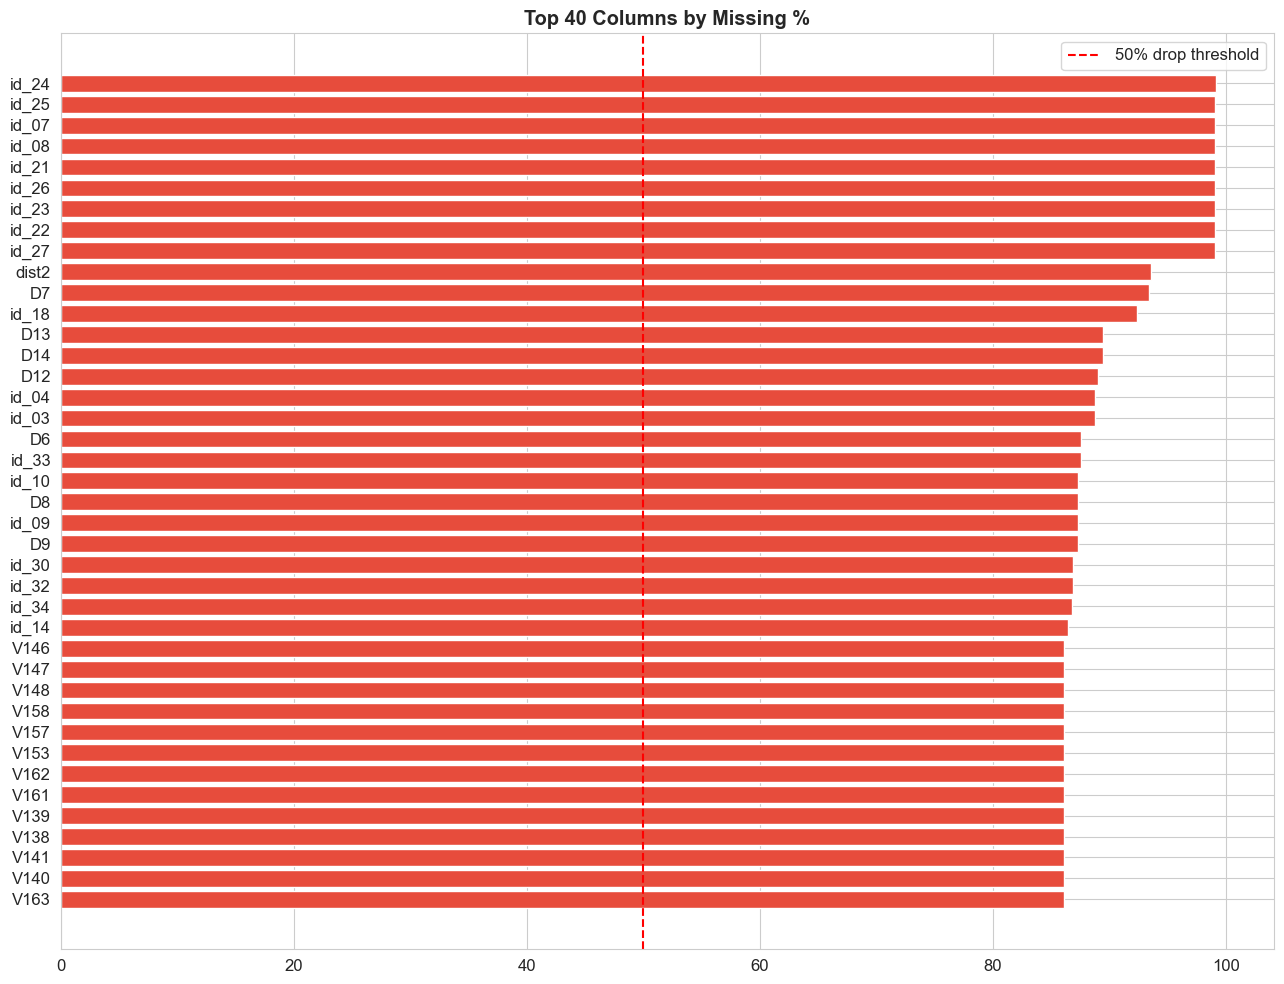

Dropped 214 columns. Shape now: (590540, 220)


In [5]:

missing = pd.DataFrame({'missing_pct': df.isnull().mean()*100})
missing = missing[missing['missing_pct']>0].sort_values('missing_pct', ascending=False)
print(f'Columns with missing: {len(missing)}  |  >50%: {(missing.missing_pct>50).sum()}')

top40 = missing.head(40)
colors = ['#e74c3c' if p>50 else '#f39c12' if p>20 else '#3498db' for p in top40.missing_pct]
fig, ax = plt.subplots(figsize=(13,10))
ax.barh(top40.index, top40.missing_pct, color=colors)
ax.axvline(50, color='red', linestyle='--', label='50% drop threshold')
ax.set_title('Top 40 Columns by Missing %', fontweight='bold')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

DROP_THRESHOLD = 50
cols_to_drop = missing[missing.missing_pct > DROP_THRESHOLD].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns. Shape now: {df_clean.shape}')

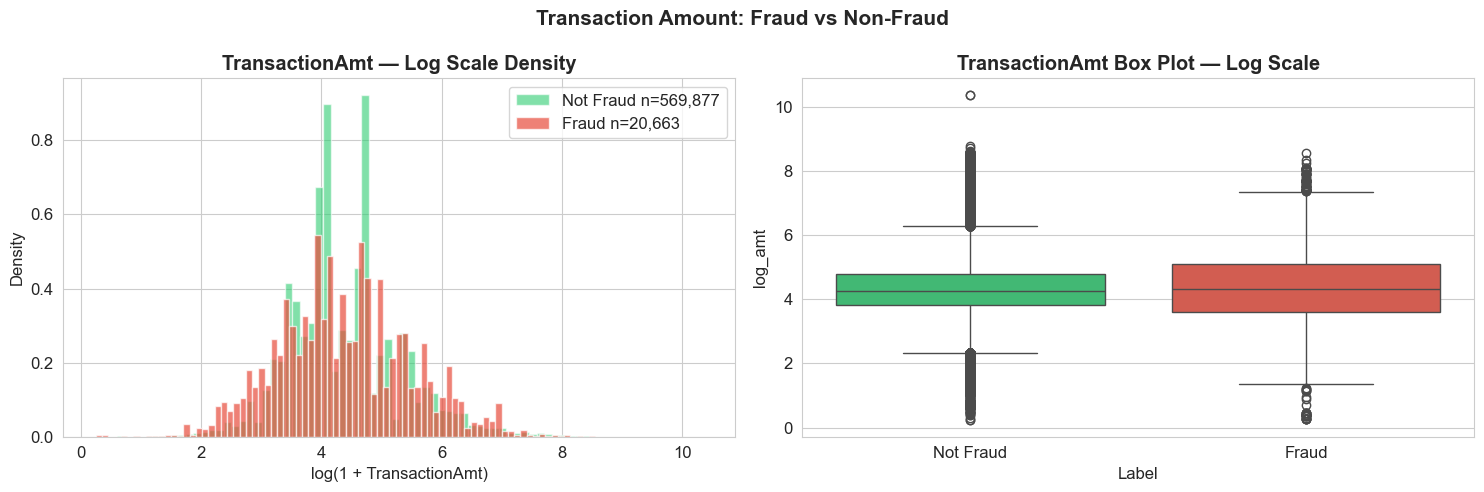

Mann-Whitney p-value: 2.26e-01 → distributions are significantly different: False


In [6]:

fraud_amt     = df[df.isFraud==1]['TransactionAmt']
non_fraud_amt = df[df.isFraud==0]['TransactionAmt']

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].hist(np.log1p(non_fraud_amt), bins=80, alpha=0.6, color='#2ecc71', density=True, label=f'Not Fraud n={len(non_fraud_amt):,}')
axes[0].hist(np.log1p(fraud_amt),     bins=80, alpha=0.7, color='#e74c3c', density=True, label=f'Fraud n={len(fraud_amt):,}')
axes[0].set_xlabel('log(1 + TransactionAmt)'); axes[0].set_ylabel('Density')
axes[0].set_title('TransactionAmt — Log Scale Density', fontweight='bold')
axes[0].legend()

plot_df = pd.DataFrame({'log_amt':np.log1p(df['TransactionAmt']),
                        'Label':df['isFraud'].map({0:'Not Fraud',1:'Fraud'})})
sns.boxplot(data=plot_df, x='Label', y='log_amt',
            palette={'Not Fraud':'#2ecc71','Fraud':'#e74c3c'}, ax=axes[1])
axes[1].set_title('TransactionAmt Box Plot — Log Scale', fontweight='bold')
plt.suptitle('Transaction Amount: Fraud vs Non-Fraud', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/transaction_amt.png', dpi=150, bbox_inches='tight')
plt.show()

stat, p = stats.mannwhitneyu(fraud_amt, non_fraud_amt)
print(f'Mann-Whitney p-value: {p:.2e} → distributions are significantly different: {p<0.05}')

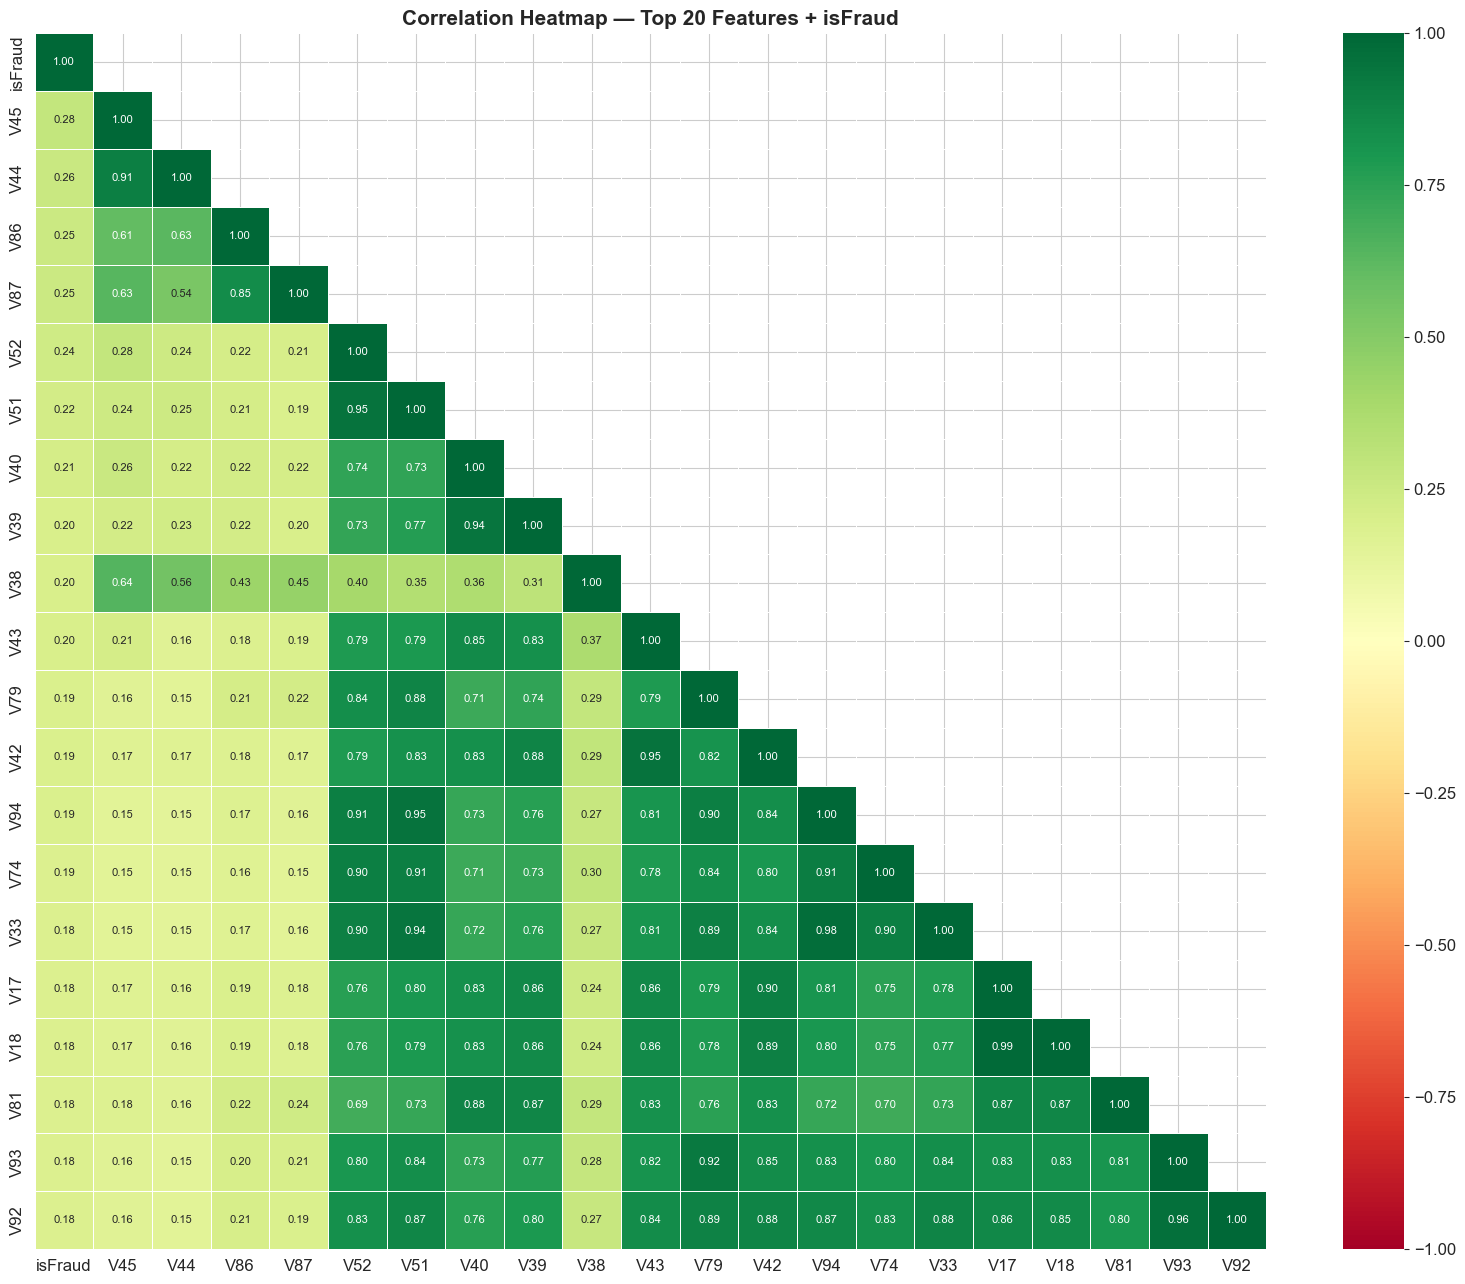

✅ Task 1 complete. Saved data/merged_clean.csv


In [7]:

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr_target = df_clean[num_cols].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
top20 = corr_target.head(20).index.tolist()

corr_matrix = df_clean[['isFraud']+top20].corr()
fig, ax = plt.subplots(figsize=(16,13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':8}, ax=ax)
ax.set_title('Correlation Heatmap — Top 20 Features + isFraud', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
df_clean.to_csv('data/merged_clean.csv', index=False)
print('✅ Task 1 complete. Saved data/merged_clean.csv')

---
# TASK 2 — Feature Engineering


In [8]:

df2 = pd.read_csv('data/merged_clean.csv')
print(f'Loaded: {df2.shape}')

Loaded: (590540, 220)


Time features created: hour, day, week, is_night


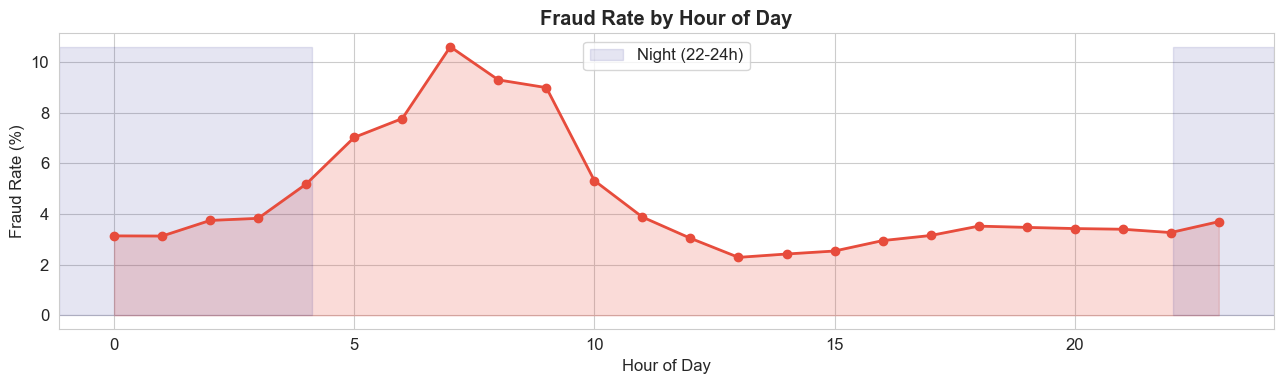

In [9]:
df2['hour']    = (df2['TransactionDT'] // 3600) % 24
df2['day']     = (df2['TransactionDT'] // (3600*24)) % 7
df2['week']    = df2['TransactionDT']  // (3600*24*7)
df2['is_night'] = ((df2['hour'] >= 22) | (df2['hour'] <= 5)).astype(int)

print('Time features created: hour, day, week, is_night')

hourly_fraud = df2.groupby('hour')['isFraud'].mean()*100
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='#e74c3c', linewidth=2)
ax.fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.2, color='#e74c3c')
ax.axhspan(0, hourly_fraud.max(), xmin=22/24, xmax=1, alpha=0.1, color='navy', label='Night (22-24h)')
ax.axhspan(0, hourly_fraud.max(), xmin=0,    xmax=5/24,  alpha=0.1, color='navy')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Hour of Day', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('charts/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:

df2['log_TransactionAmt'] = np.log1p(df2['TransactionAmt'])
df2['amt_cents']  = (df2['TransactionAmt'] % 1).round(2)  # decimal part (round amounts = suspicious)
df2['amt_is_round'] = (df2['amt_cents'] == 0).astype(int)

for grp_col in ['card1', 'card2']:
    if grp_col in df2.columns:
        col_mean = f'{grp_col}_amt_mean'
        col_count= f'{grp_col}_count'
        agg = df2.groupby(grp_col)['TransactionAmt'].agg(['mean','count'])
        df2[col_mean]  = df2[grp_col].map(agg['mean'])
        df2[col_count] = df2[grp_col].map(agg['count'])
        df2[f'{grp_col}_amt_deviation'] = df2['TransactionAmt'] - df2[col_mean]

print('Amount features: log_TransactionAmt, amt_cents, amt_is_round, card-level aggregates')

Amount features: log_TransactionAmt, amt_cents, amt_is_round, card-level aggregates


In [11]:
for col in ['P_emaildomain','R_emaildomain']:
    if col in df2.columns:
        df2[f'{col}_tld'] = df2[col].str.split('.').str[-1].fillna('unknown')
        # Count-encode
        vc = df2[col].value_counts()
        df2[f'{col}_freq'] = df2[col].map(vc).fillna(0)
        # Flag high-risk domains (Gmail/Yahoo mismatches are common in fraud)
        df2[f'{col}_is_free'] = df2[col].isin(['gmail.com','yahoo.com','hotmail.com','outlook.com']).astype(int)

if 'P_emaildomain' in df2.columns and 'R_emaildomain' in df2.columns:
    df2['email_same'] = (df2['P_emaildomain']==df2['R_emaildomain']).astype(int)

print('Email domain features created')

Email domain features created


In [12]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df2.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df2[col] = df2[col].fillna('__missing__')
    df2[col] = le.fit_transform(df2[col].astype(str))

num_cols = df2.select_dtypes(include=np.number).columns.tolist()
df2[num_cols] = df2[num_cols].fillna(df2[num_cols].median())

print(f'After encoding & imputing — nulls remaining: {df2.isnull().sum().sum()}')
print(f'Final feature set shape: {df2.shape}')

df2.to_csv('data/featured.csv', index=False)
print(' Task 2 complete. Saved data/featured.csv')

After encoding & imputing — nulls remaining: 0
Final feature set shape: (590540, 236)
 Task 2 complete. Saved data/featured.csv


---
# TASK 3 — Model Training: LightGBM vs XGBoost + SMOTE


In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb
import pickle

df3 = pd.read_csv('data/featured.csv')

TARGET = 'isFraud'
DROP   = ['TransactionID', TARGET]
FEATURES = [c for c in df3.columns if c not in DROP]

X = df3[FEATURES]
y = df3[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean():.4f}')

Train: (472432, 234)  |  Test: (118108, 234)
Train fraud rate: 0.0350


In [14]:

print('Applying SMOTE...')
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f'After SMOTE — Fraud: {y_train_sm.sum():,}  |  Not Fraud: {(y_train_sm==0).sum():,}')

Applying SMOTE...
After SMOTE — Fraud: 455,902  |  Not Fraud: 455,902


In [15]:
lgb_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    max_depth=-1, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

lgb_prob = lgb_model.predict_proba(X_test)[:,1]
lgb_pred = (lgb_prob >= 0.5).astype(int)

print('=== LightGBM ===')
print(f'ROC-AUC : {roc_auc_score(y_test, lgb_prob):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, lgb_prob):.4f}')
print(classification_report(y_test, lgb_pred, target_names=['Not Fraud','Fraud']))

=== LightGBM ===
ROC-AUC : 0.9516
PR-AUC  : 0.7402
              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99    113975
       Fraud       0.89      0.52      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.94      0.76      0.82    118108
weighted avg       0.98      0.98      0.98    118108



In [16]:
scale_pos = (y_train_sm==0).sum() / y_train_sm.sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, eval_metric='aucpr',
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0, use_label_encoder=False
)
xgb_model.fit(X_train_sm, y_train_sm,
              eval_set=[(X_test, y_test)], verbose=False)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

print('=== XGBoost ===')
print(f'ROC-AUC : {roc_auc_score(y_test, xgb_prob):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, xgb_prob):.4f}')
print(classification_report(y_test, xgb_pred, target_names=['Not Fraud','Fraud']))

=== XGBoost ===
ROC-AUC : 0.9280
PR-AUC  : 0.6513
              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99    113975
       Fraud       0.85      0.46      0.60      4133

    accuracy                           0.98    118108
   macro avg       0.92      0.73      0.79    118108
weighted avg       0.98      0.98      0.98    118108



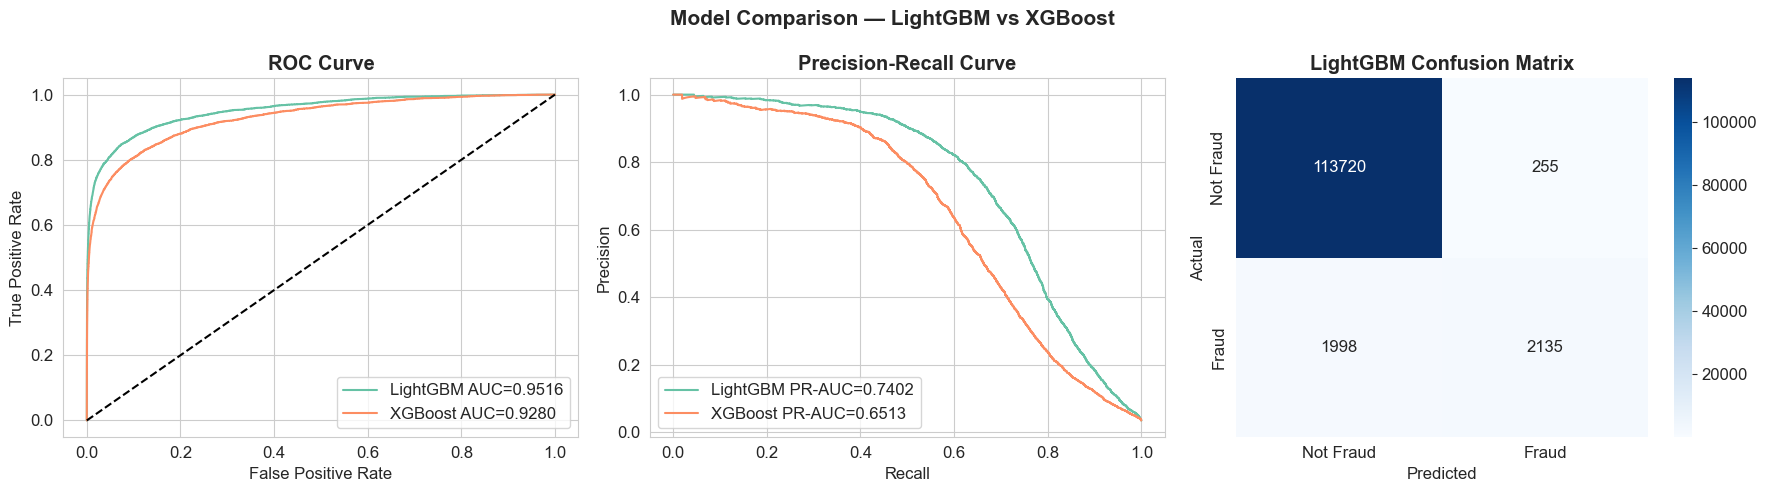

Task 3 complete. Saved model_comparison.png and dashboard/model.pkl


In [17]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
for name, prob in [('LightGBM', lgb_prob), ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y_test, prob):.4f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend()
for name, prob in [('LightGBM', lgb_prob), ('XGBoost', xgb_prob)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, label=f'{name} PR-AUC={average_precision_score(y_test, prob):.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend()

cm = confusion_matrix(y_test, lgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Not Fraud','Fraud'], yticklabels=['Not Fraud','Fraud'])
axes[2].set_title('LightGBM Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('Actual'); axes[2].set_xlabel('Predicted')

plt.suptitle('Model Comparison — LightGBM vs XGBoost', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
os.makedirs('dashboard', exist_ok=True)
with open('dashboard/model.pkl','wb') as f:
    pickle.dump({'model': lgb_model, 'features': FEATURES}, f)
print('Task 3 complete. Saved model_comparison.png and dashboard/model.pkl')

---
# TASK 4 — Explainable AI with SHAP


In [18]:
import shap
shap.initjs()
explainer   = shap.TreeExplainer(lgb_model)

sample_idx  = X_test.sample(min(2000, len(X_test)), random_state=42).index
X_sample    = X_test.loc[sample_idx]
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP values computed for {len(X_sample)} samples × {sv.shape[1]} features')

SHAP values computed for 2000 samples × 234 features


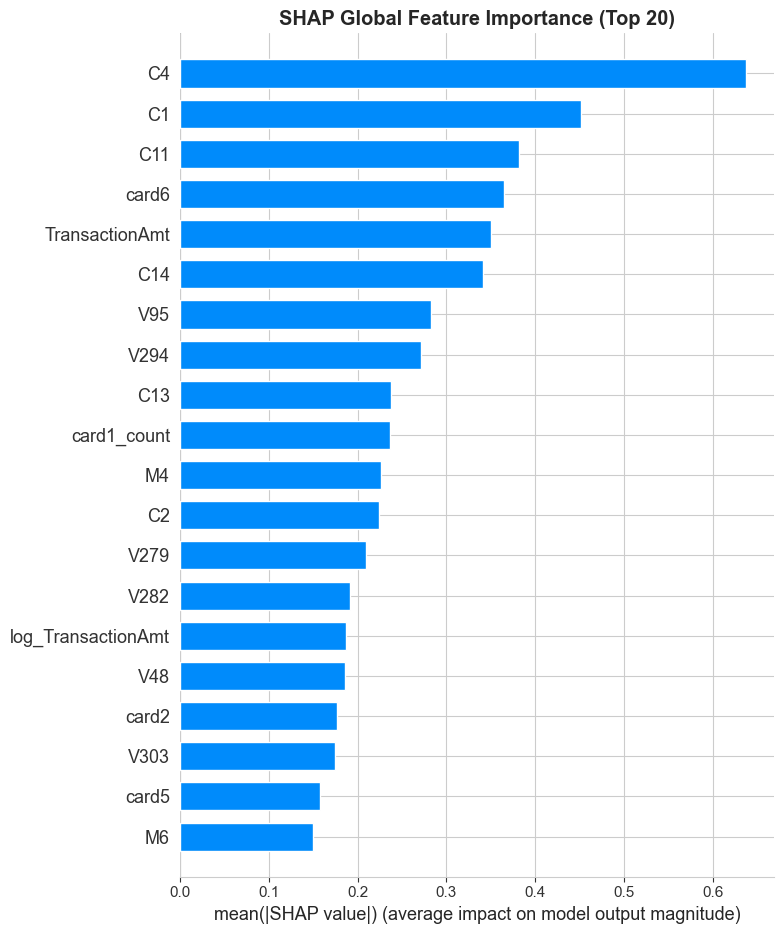

In [19]:
plt.figure(figsize=(12,8))
shap.summary_plot(sv, X_sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Global Feature Importance (Top 20)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

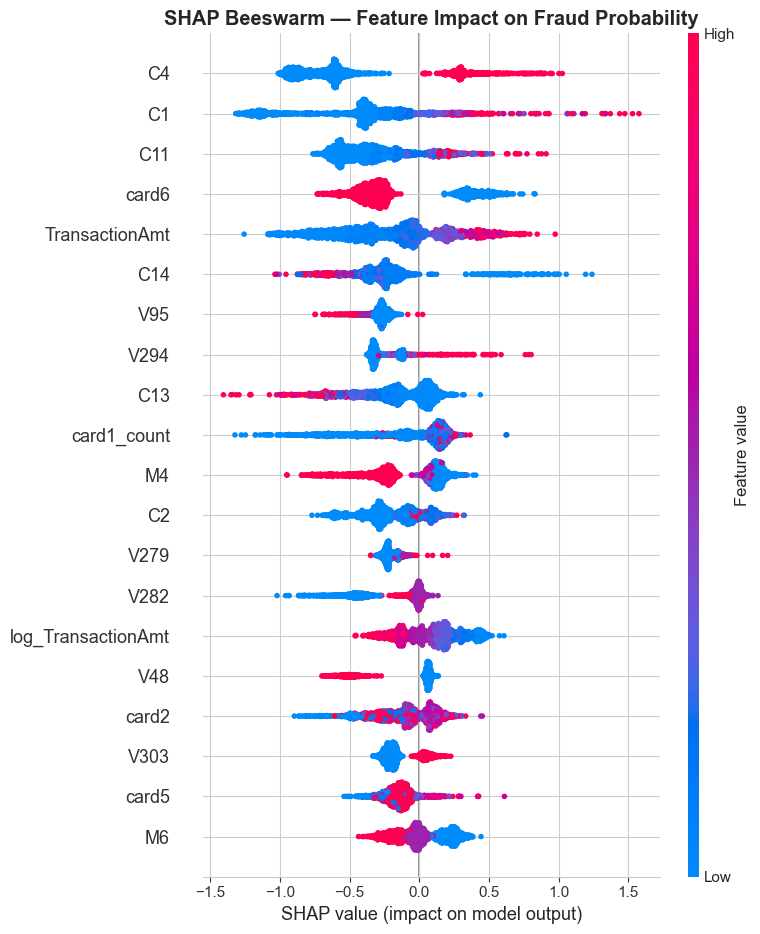

In [20]:
plt.figure(figsize=(12,8))
shap.summary_plot(sv, X_sample, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining transaction index 236117
Predicted fraud probability: 0.9984


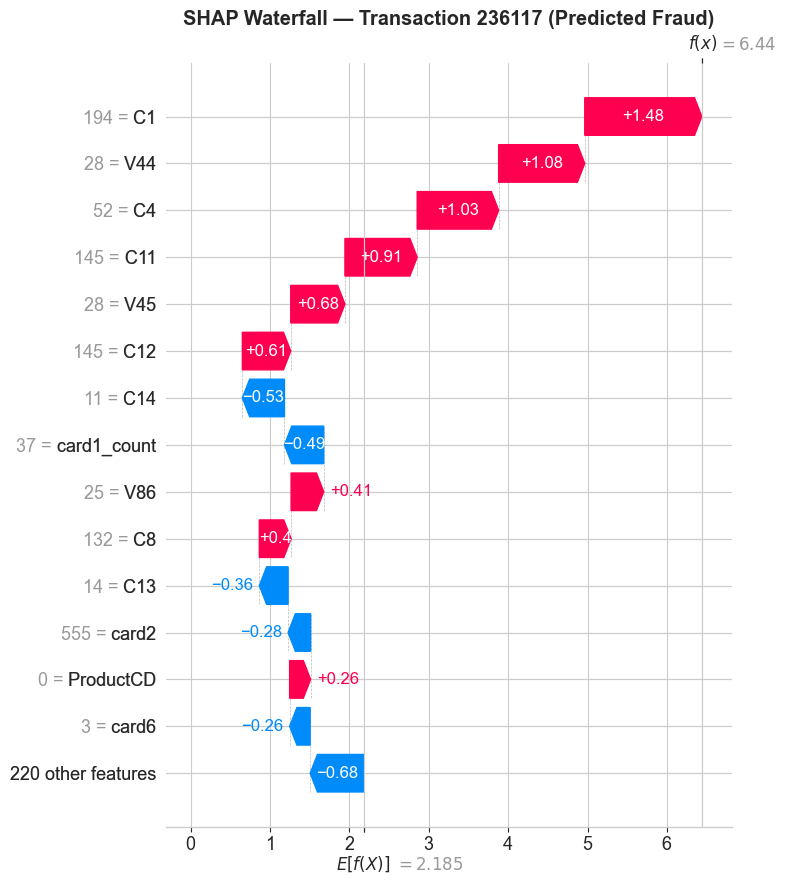

In [21]:
sample_probs = lgb_model.predict_proba(X_sample)[:,1]
fraud_idx_local = np.argmax(sample_probs)          # highest prob in sample
fraud_idx_global = X_sample.index[fraud_idx_local]

print(f'Explaining transaction index {fraud_idx_global}')
print(f'Predicted fraud probability: {sample_probs[fraud_idx_local]:.4f}')
exp = shap.Explanation(
    values         = sv[fraud_idx_local],
    base_values    = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data           = X_sample.iloc[fraud_idx_local],
    feature_names  = FEATURES
)
plt.figure(figsize=(12,7))
shap.plots.waterfall(exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Transaction {fraud_idx_global} (Predicted Fraud)', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
top_shap_feat = pd.Series(np.abs(sv).mean(0), index=FEATURES).sort_values(ascending=False)

print('=' * 60)
print('  NON-TECHNICAL EXPLANATION — Top 5 Fraud Signals')
print('=' * 60)
for i, (feat, importance) in enumerate(top_shap_feat.head(5).items(), 1):
    val = X_sample.iloc[fraud_idx_local][feat]
    contrib = sv[fraud_idx_local, FEATURES.index(feat)]
    direction = '⬆ increases' if contrib > 0 else '⬇ decreases'
    print(f'{i}. Feature [{feat}] = {val:.2f}')
    print(f'   → This {direction} fraud probability by {abs(contrib):.4f} SHAP units.')
    print()

print('Task 4 complete. Saved shap_summary.png and charts/shap_waterfall.png')

  NON-TECHNICAL EXPLANATION — Top 5 Fraud Signals
1. Feature [C4] = 52.00
   → This ⬆ increases fraud probability by 1.0265 SHAP units.

2. Feature [C1] = 194.00
   → This ⬆ increases fraud probability by 1.4752 SHAP units.

3. Feature [C11] = 145.00
   → This ⬆ increases fraud probability by 0.9103 SHAP units.

4. Feature [card6] = 3.00
   → This ⬇ decreases fraud probability by 0.2587 SHAP units.

5. Feature [TransactionAmt] = 67.07
   → This ⬇ decreases fraud probability by 0.0071 SHAP units.

Task 4 complete. Saved shap_summary.png and charts/shap_waterfall.png


---
# TASK 5 — Risk Tier Classification & Analysis


In [23]:
test_probs = lgb_model.predict_proba(X_test)[:,1]

results = X_test.copy()
results['fraud_prob']   = test_probs
results['actual_fraud'] = y_test.values

def assign_tier(prob):
    if prob >= 0.75: return 'Critical Risk'
    if prob >= 0.40: return 'Suspicious'
    return 'Clear'

results['risk_tier'] = results['fraud_prob'].apply(assign_tier)

tier_counts = results['risk_tier'].value_counts()
print('=== Risk Tier Distribution ===')
for tier in ['Critical Risk','Suspicious','Clear']:
    n = tier_counts.get(tier,0)
    pct = n/len(results)*100
    print(f'  {tier:<14}: {n:>6,} ({pct:.1f}%)')

=== Risk Tier Distribution ===
  Critical Risk :  1,743 (1.5%)
  Suspicious    :  1,004 (0.9%)
  Clear         : 115,361 (97.7%)


In [24]:

tier_stats = results.groupby('risk_tier').agg(
    count        = ('fraud_prob','count'),
    avg_prob     = ('fraud_prob','mean'),
    actual_fraud = ('actual_fraud','mean'),
).round(4)

if 'log_TransactionAmt' in results.columns:
    results['TransactionAmt_est'] = np.expm1(results['log_TransactionAmt'])
    tier_stats['avg_amt'] = results.groupby('risk_tier')['TransactionAmt_est'].mean().round(2)

print(tier_stats.to_string())

                count  avg_prob  actual_fraud  avg_amt
risk_tier                                             
Clear          115361    0.0191        0.0155   134.77
Critical Risk    1743    0.9276        0.9489   128.69
Suspicious       1004    0.5585        0.6853   155.07


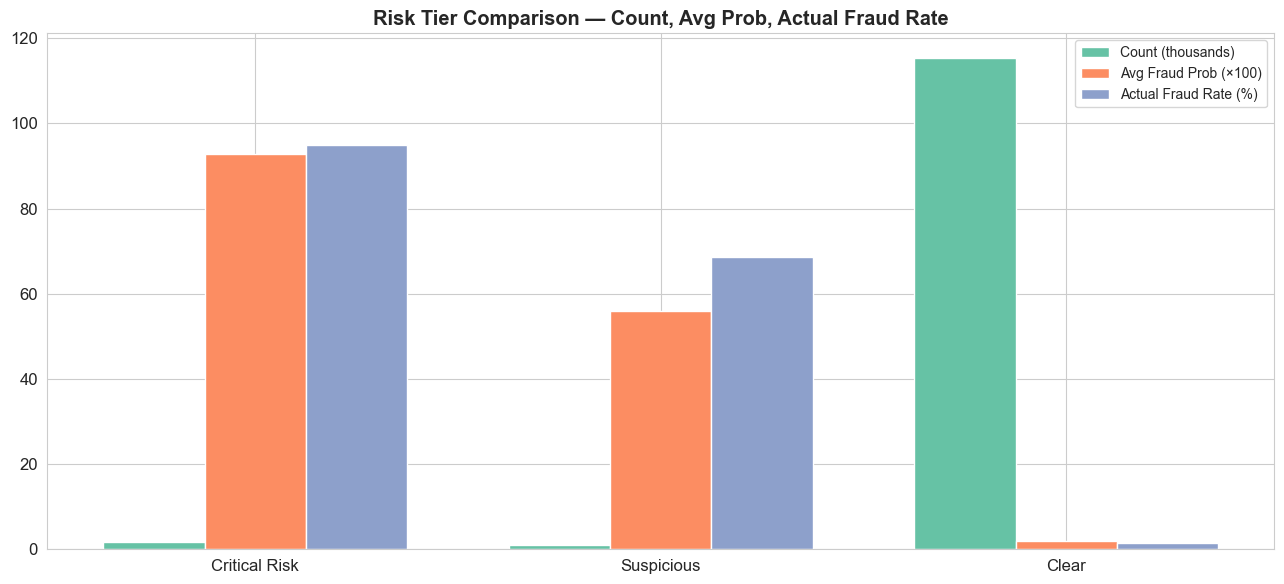

In [25]:

tier_order  = ['Critical Risk','Suspicious','Clear']
tier_colors = {'Critical Risk':'#e74c3c','Suspicious':'#f39c12','Clear':'#2ecc71'}

metrics = {
    'Count (thousands)':     [tier_counts.get(t,0)/1000 for t in tier_order],
    'Avg Fraud Prob (×100)': [tier_stats.loc[t,'avg_prob']*100 if t in tier_stats.index else 0 for t in tier_order],
    'Actual Fraud Rate (%)': [tier_stats.loc[t,'actual_fraud']*100 if t in tier_stats.index else 0 for t in tier_order],
}

x = np.arange(len(tier_order))
width = 0.25
fig, ax = plt.subplots(figsize=(13,6))
for i, (label, vals) in enumerate(metrics.items()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=label, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(tier_order, fontsize=12)
ax.set_title('Risk Tier Comparison — Count, Avg Prob, Actual Fraud Rate', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('charts/risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

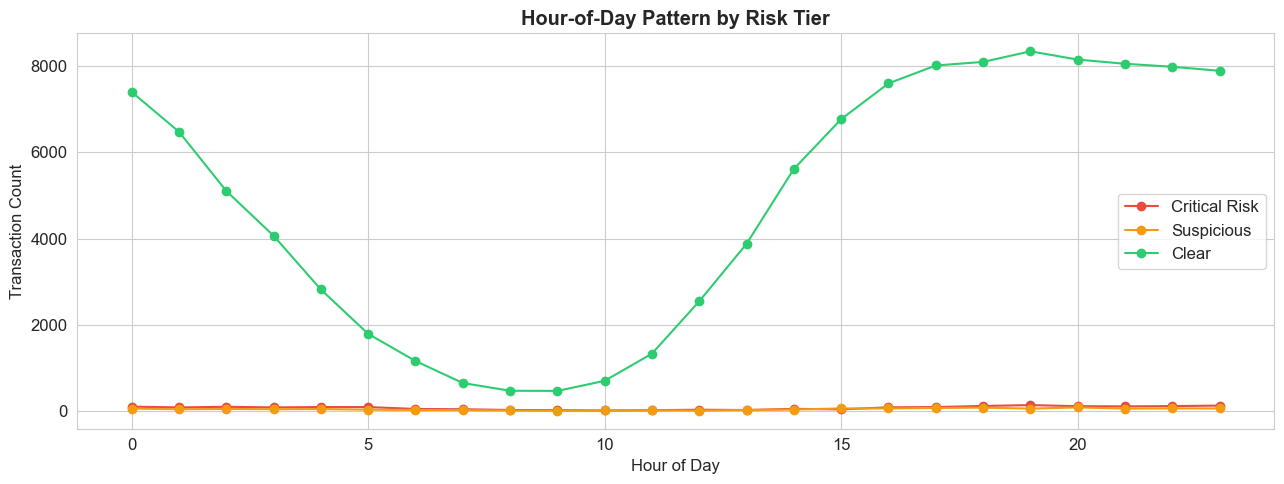

In [26]:

if 'hour' in results.columns:
    fig, ax = plt.subplots(figsize=(13,5))
    for tier, color in tier_colors.items():
        subset = results[results['risk_tier']==tier]
        hourly = subset.groupby('hour').size()
        if len(hourly):
            ax.plot(hourly.index, hourly.values, marker='o', label=tier, color=color)
    ax.set_xlabel('Hour of Day'); ax.set_ylabel('Transaction Count')
    ax.set_title('Hour-of-Day Pattern by Risk Tier', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('charts/tier_hourly.png', dpi=150, bbox_inches='tight')
    plt.show()

In [27]:
critical = results[results['risk_tier']=='Critical Risk']

print('=== TOP 3 FRAUD PATTERNS IN CRITICAL RISK TIER ===')
print()

if 'TransactionAmt_est' in critical.columns:
    print(f'1. HIGH TRANSACTION AMOUNT')
    print(f'   Critical Risk avg: ${critical.TransactionAmt_est.mean():.2f}')
    print(f'   Overall avg      : ${results.TransactionAmt_est.mean():.2f}')
    print()

if 'is_night' in critical.columns:
    night_pct = critical['is_night'].mean()*100
    print(f'2. NIGHT-TIME TRANSACTIONS (22:00-05:00)')
    print(f'   Night % in Critical Risk : {night_pct:.1f}%')
    print(f'   Night % overall          : {results.is_night.mean()*100:.1f}%')
    print()
if 'amt_is_round' in critical.columns:
    round_pct = critical['amt_is_round'].mean()*100
    print(f'3. ROUND DOLLAR AMOUNTS (no cents)')
    print(f'   Round amt % in Critical Risk : {round_pct:.1f}%')
    print(f'   Round amt % overall          : {results.amt_is_round.mean()*100:.1f}%')

results.to_csv('data/results_with_tiers.csv', index=False)
print('\nTask 5 complete. Saved charts/risk_tiers.png and data/results_with_tiers.csv')

=== TOP 3 FRAUD PATTERNS IN CRITICAL RISK TIER ===

1. HIGH TRANSACTION AMOUNT
   Critical Risk avg: $128.69
   Overall avg      : $134.85

2. NIGHT-TIME TRANSACTIONS (22:00-05:00)
   Night % in Critical Risk : 45.2%
   Night % overall          : 37.8%

3. ROUND DOLLAR AMOUNTS (no cents)
   Round amt % in Critical Risk : 41.1%
   Round amt % overall          : 51.7%

Task 5 complete. Saved charts/risk_tiers.png and data/results_with_tiers.csv


---
# TASK 7 — Visualizations 



In [28]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score
import plotly.express as px
import plotly.graph_objects as go
import shap

warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e8e8e8',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

PALETTE = {
    'fraud':      '#E24B4A',
    'no_fraud':   '#1D9E75',
    'critical':   '#E24B4A',
    'suspicious': '#EF9F27',
    'clear':      '#1D9E75',
    'shap':       '#378ADD',
    'pr_curve':   '#534AB7',
    'baseline':   '#888780',
}
print(' Setup complete')

 Setup complete


In [29]:
results  = pd.read_csv('data/results_with_tiers.csv')
featured = pd.read_csv('data/featured.csv')

with open('dashboard/model.pkl', 'rb') as f:
    obj = pickle.load(f)
model    = obj['model']
features = obj['features']

TARGET = 'isFraud'
X      = featured[features]
y      = featured[TARGET]

print(f'results_with_tiers : {results.shape}')
print(f'featured           : {featured.shape}')
print(f'Features           : {len(features)}')
print(f'Fraud rate         : {y.mean()*100:.2f}%')

results_with_tiers : (118108, 238)
featured           : (590540, 236)
Features           : 234
Fraud rate         : 3.50%


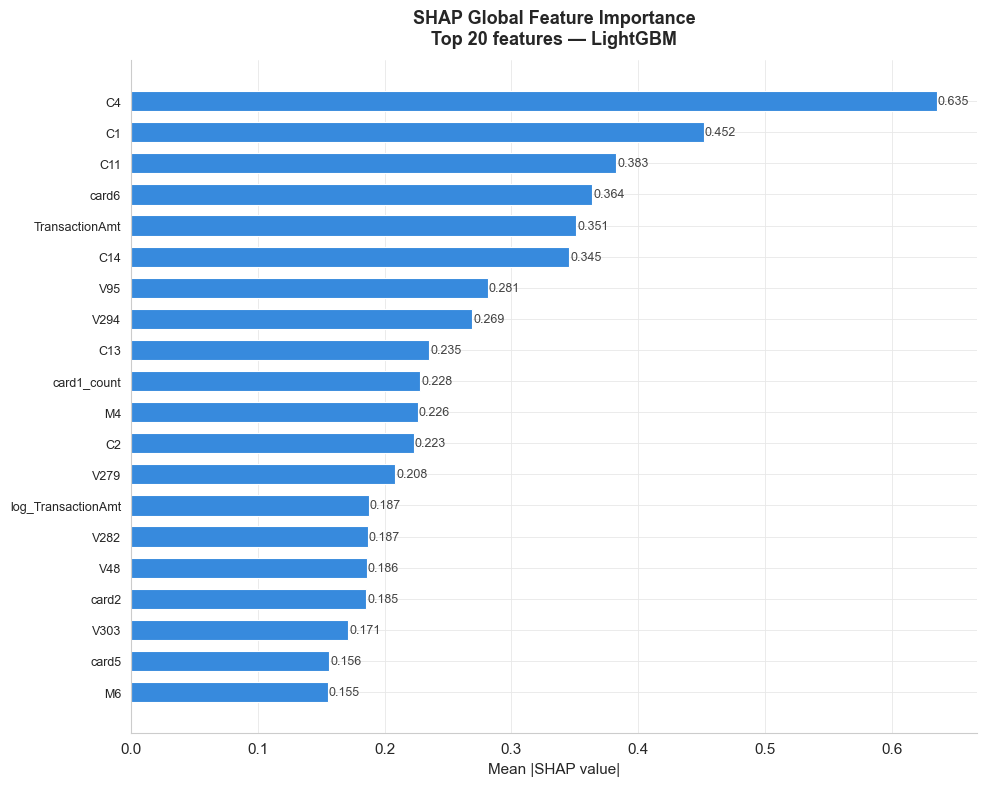

 Saved → charts/shap_global_summary.png


In [30]:
sample      = X.sample(min(2000, len(X)), random_state=42)
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_shap = pd.Series(np.abs(sv).mean(0), index=features).sort_values(ascending=True)
top20     = mean_shap.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top20.index, top20.values,
               color=PALETTE['shap'], edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars, top20.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#444')

ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('SHAP Global Feature Importance\nTop 20 features — LightGBM',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='y', labelsize=9)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.savefig('charts/shap_global_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/shap_global_summary.png')

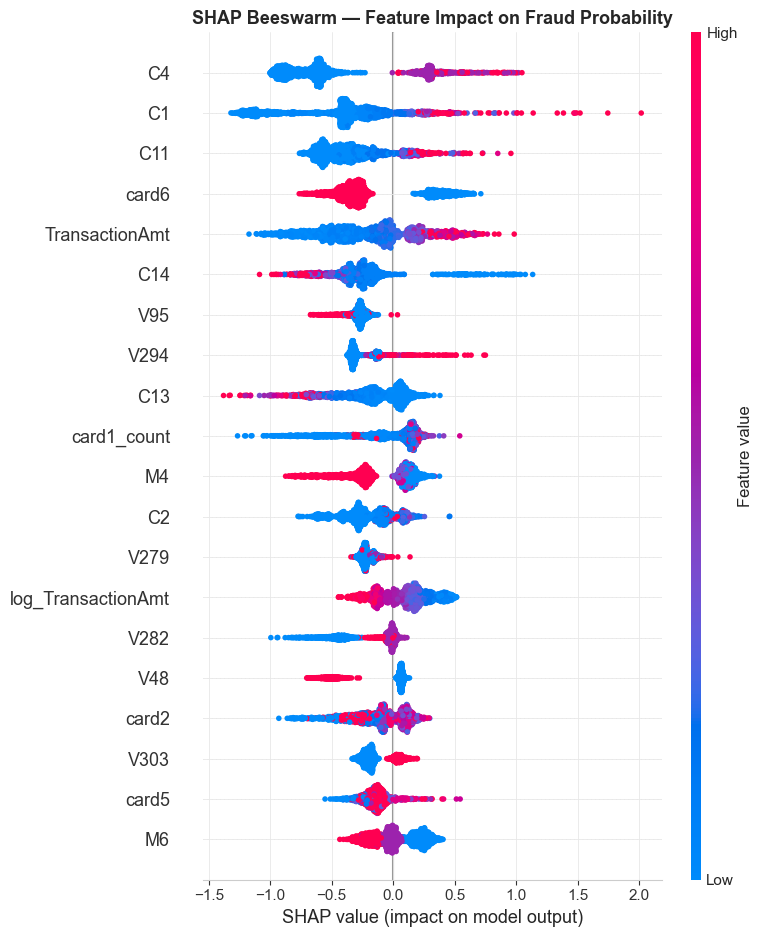

 Saved → shap_summary.png  (submission copy)


In [31]:

plt.figure(figsize=(11, 8))
shap.summary_plot(sv, sample, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Probability',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → shap_summary.png  (submission copy)')

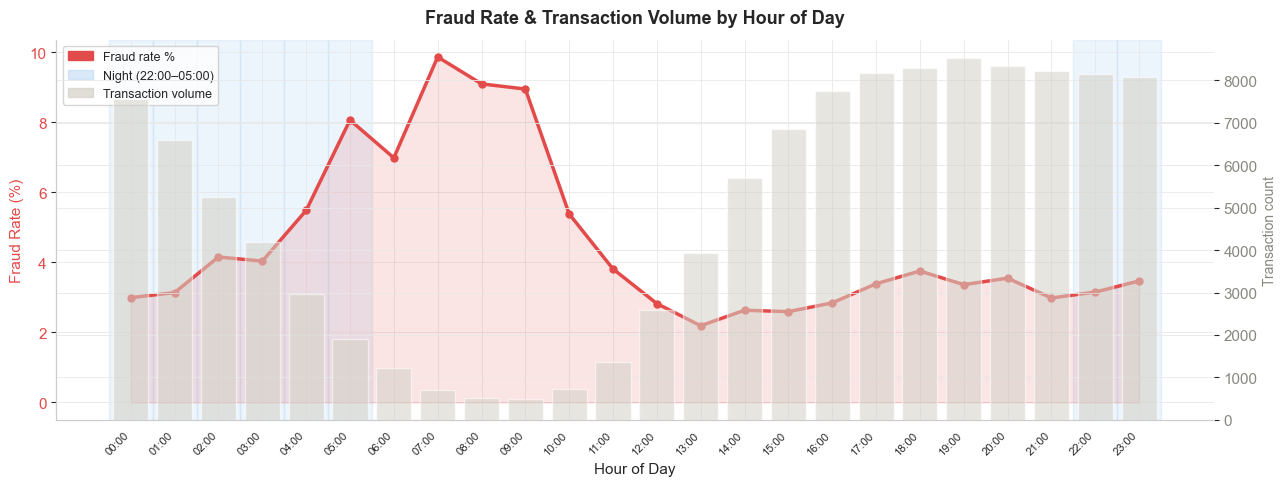

 Saved → charts/fraud_rate_by_hour.png


In [32]:
if 'hour' not in results.columns:
    results['hour'] = (results.get('TransactionDT', pd.Series(0, index=results.index)) // 3600) % 24

hourly = results.groupby('hour')['actual_fraud'].agg(['mean','count']).reset_index()
hourly.columns = ['hour','fraud_rate','count']
hourly['fraud_rate_pct'] = hourly['fraud_rate'] * 100

fig, ax1 = plt.subplots(figsize=(13, 5))

for h in range(24):
    if h >= 22 or h <= 5:
        ax1.axvspan(h-0.5, h+0.5, color='#B5D4F4', alpha=0.25, zorder=0)

ax2 = ax1.twinx()
ax2.bar(hourly['hour'], hourly['count'], color='#d3d1c7',
        alpha=0.55, width=0.8, zorder=1)
ax2.set_ylabel('Transaction count', color='#888780', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#888780')
ax2.spines['top'].set_visible(False)

ax1.plot(hourly['hour'], hourly['fraud_rate_pct'],
         color=PALETTE['fraud'], linewidth=2.5, marker='o', markersize=5, zorder=3)
ax1.fill_between(hourly['hour'], hourly['fraud_rate_pct'],
                 alpha=0.15, color=PALETTE['fraud'], zorder=2)

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Fraud Rate (%)', color=PALETTE['fraud'], fontsize=11)
ax1.tick_params(axis='y', labelcolor=PALETTE['fraud'])
ax1.set_xticks(range(24))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)

night_patch = mpatches.Patch(color='#B5D4F4', alpha=0.5, label='Night (22:00–05:00)')
fraud_line  = mpatches.Patch(color=PALETTE['fraud'],   label='Fraud rate %')
vol_patch   = mpatches.Patch(color='#d3d1c7', alpha=0.7, label='Transaction volume')
ax1.legend(handles=[fraud_line, night_patch, vol_patch], loc='upper left', fontsize=9)
ax1.set_title('Fraud Rate & Transaction Volume by Hour of Day',
              fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('charts/fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/fraud_rate_by_hour.png')

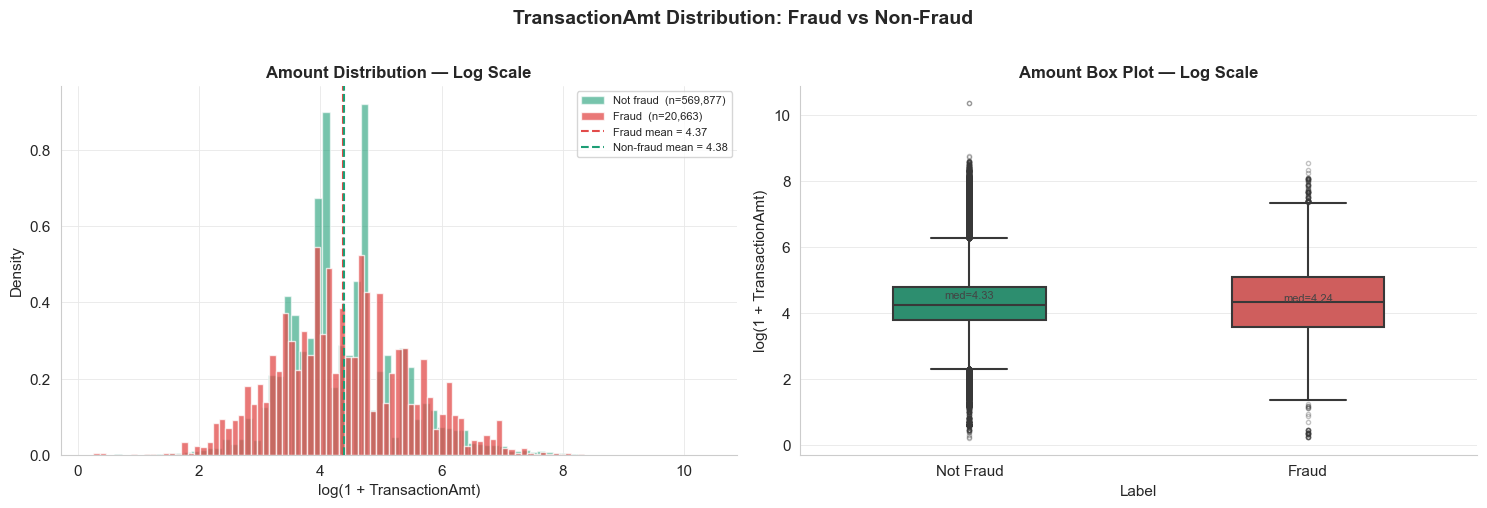

 Saved → charts/transaction_amt_distribution.png


In [33]:
if 'log_TransactionAmt' in featured.columns:
    log_amt   = featured['log_TransactionAmt']
    fraud_flg = featured[TARGET]
else:
    log_amt   = np.log1p(featured['TransactionAmt'])
    fraud_flg = featured[TARGET]

fraud_log = log_amt[fraud_flg == 1]
nf_log    = log_amt[fraud_flg == 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(nf_log,    bins=80, alpha=0.6,  color=PALETTE['no_fraud'],
             density=True, label=f'Not fraud  (n={len(nf_log):,})')
axes[0].hist(fraud_log, bins=80, alpha=0.75, color=PALETTE['fraud'],
             density=True, label=f'Fraud  (n={len(fraud_log):,})')
axes[0].axvline(fraud_log.mean(), color=PALETTE['fraud'],    linestyle='--', linewidth=1.5,
                label=f'Fraud mean = {fraud_log.mean():.2f}')
axes[0].axvline(nf_log.mean(),    color=PALETTE['no_fraud'], linestyle='--', linewidth=1.5,
                label=f'Non-fraud mean = {nf_log.mean():.2f}')
axes[0].set_xlabel('log(1 + TransactionAmt)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Amount Distribution — Log Scale', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

plot_df = pd.DataFrame({'log_amt': log_amt,
                        'Label': fraud_flg.map({0:'Not Fraud', 1:'Fraud'})})
sns.boxplot(data=plot_df, x='Label', y='log_amt',
            palette={'Not Fraud': PALETTE['no_fraud'], 'Fraud': PALETTE['fraud']},
            width=0.45, linewidth=1.5,
            flierprops={'marker':'.','alpha':0.3}, ax=axes[1])
axes[1].set_ylabel('log(1 + TransactionAmt)', fontsize=11)
axes[1].set_title('Amount Box Plot — Log Scale', fontsize=12, fontweight='bold')

for i, (label, group) in enumerate(plot_df.groupby('Label')):
    axes[1].text(i, group['log_amt'].median() + 0.05,
                 f'med={group["log_amt"].median():.2f}',
                 ha='center', va='bottom', fontsize=8, color='#444')

plt.suptitle('TransactionAmt Distribution: Fraud vs Non-Fraud',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/transaction_amt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/transaction_amt_distribution.png')

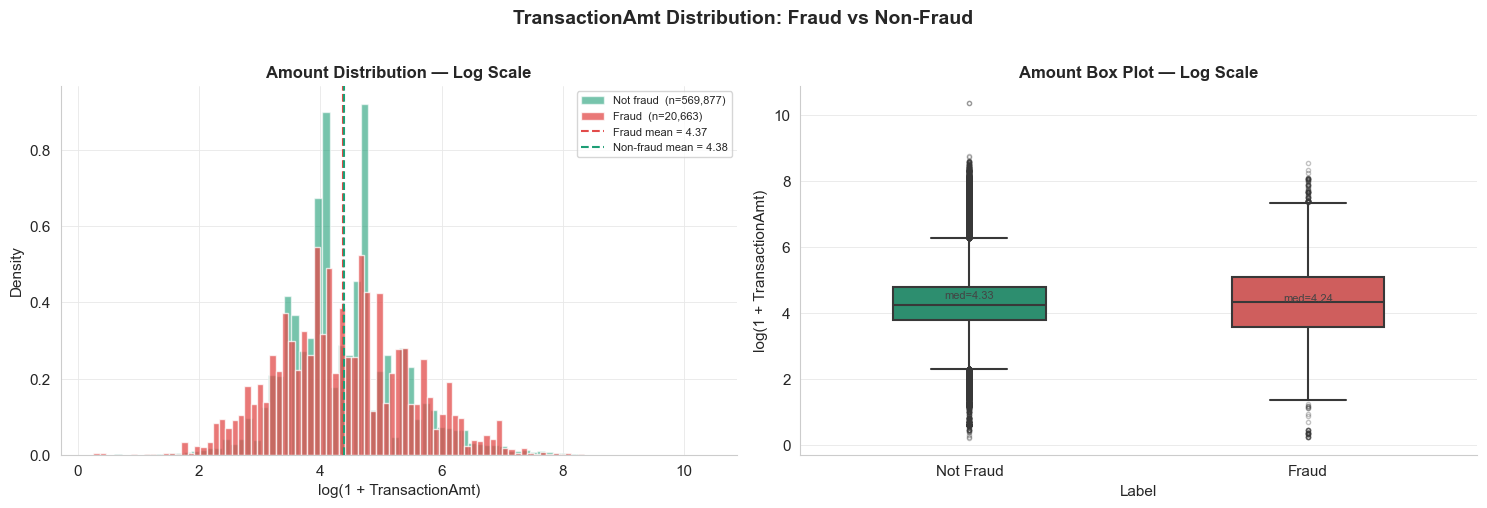

 Saved → charts/transaction_amt_distribution.png


In [34]:
if 'log_TransactionAmt' in featured.columns:
    log_amt   = featured['log_TransactionAmt']
    fraud_flg = featured[TARGET]
else:
    log_amt   = np.log1p(featured['TransactionAmt'])
    fraud_flg = featured[TARGET]

fraud_log = log_amt[fraud_flg == 1]
nf_log    = log_amt[fraud_flg == 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(nf_log,    bins=80, alpha=0.6,  color=PALETTE['no_fraud'],
             density=True, label=f'Not fraud  (n={len(nf_log):,})')
axes[0].hist(fraud_log, bins=80, alpha=0.75, color=PALETTE['fraud'],
             density=True, label=f'Fraud  (n={len(fraud_log):,})')
axes[0].axvline(fraud_log.mean(), color=PALETTE['fraud'],    linestyle='--', linewidth=1.5,
                label=f'Fraud mean = {fraud_log.mean():.2f}')
axes[0].axvline(nf_log.mean(),    color=PALETTE['no_fraud'], linestyle='--', linewidth=1.5,
                label=f'Non-fraud mean = {nf_log.mean():.2f}')
axes[0].set_xlabel('log(1 + TransactionAmt)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Amount Distribution — Log Scale', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

plot_df = pd.DataFrame({'log_amt': log_amt,
                        'Label': fraud_flg.map({0:'Not Fraud', 1:'Fraud'})})
sns.boxplot(data=plot_df, x='Label', y='log_amt',
            palette={'Not Fraud': PALETTE['no_fraud'], 'Fraud': PALETTE['fraud']},
            width=0.45, linewidth=1.5,
            flierprops={'marker':'.','alpha':0.3}, ax=axes[1])
axes[1].set_ylabel('log(1 + TransactionAmt)', fontsize=11)
axes[1].set_title('Amount Box Plot — Log Scale', fontsize=12, fontweight='bold')

for i, (label, group) in enumerate(plot_df.groupby('Label')):
    axes[1].text(i, group['log_amt'].median() + 0.05,
                 f'med={group["log_amt"].median():.2f}',
                 ha='center', va='bottom', fontsize=8, color='#444')

plt.suptitle('TransactionAmt Distribution: Fraud vs Non-Fraud',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/transaction_amt_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/transaction_amt_distribution.png')

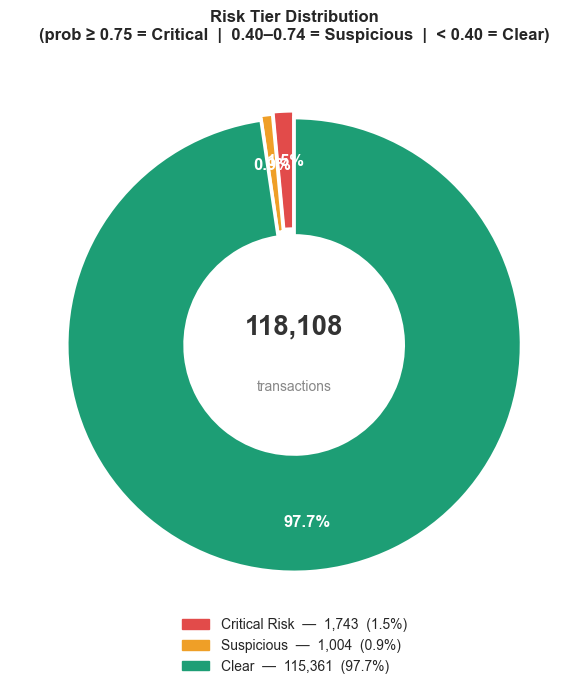

 Saved → charts/risk_tier_donut.png


In [35]:
tier_counts = results['risk_tier'].value_counts()
tier_order  = ['Critical Risk','Suspicious','Clear']
tier_colors = [PALETTE['critical'], PALETTE['suspicious'], PALETTE['clear']]
sizes       = [tier_counts.get(t, 0) for t in tier_order]
total       = sum(sizes)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=tier_colors,
    autopct='%1.1f%%', pctdistance=0.78, startangle=90,
    wedgeprops={'width':0.52, 'edgecolor':'white', 'linewidth':2.5},
    explode=(0.03, 0.02, 0),
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')

ax.text(0,  0.08, f'{total:,}', ha='center', va='center',
        fontsize=20, fontweight='bold', color='#333')
ax.text(0, -0.18, 'transactions', ha='center', va='center',
        fontsize=10, color='#888')

legend_labels = [f'{t}  —  {c:,}  ({c/total*100:.1f}%)'
                 for t, c in zip(tier_order, sizes)]
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(tier_colors, legend_labels)]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5,-0.10),
          fontsize=10, frameon=False, ncol=1)
ax.set_title('Risk Tier Distribution\n'
             '(prob ≥ 0.75 = Critical  |  0.40–0.74 = Suspicious  |  < 0.40 = Clear)',
             fontsize=12, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('charts/risk_tier_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/risk_tier_donut.png')

In [36]:
probs  = model.predict_proba(X)[:, 1]
prec, rec, thresholds = precision_recall_curve(y, probs)
pr_auc = average_precision_score(y, probs)

f1_scores  = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
opt_thresh = thresholds[best_idx]
opt_prec   = prec[best_idx]
opt_rec    = rec[best_idx]
opt_f1     = f1_scores[best_idx]

print(f'PR-AUC            : {pr_auc:.4f}')
print(f'Optimal threshold : {opt_thresh:.4f}')
print(f'Precision         : {opt_prec:.4f}')
print(f'Recall            : {opt_rec:.4f}')
print(f'F1-score          : {opt_f1:.4f}')

PR-AUC            : 0.8000
Optimal threshold : 0.2951
Precision         : 0.8332
Recall            : 0.6800
F1-score          : 0.7488


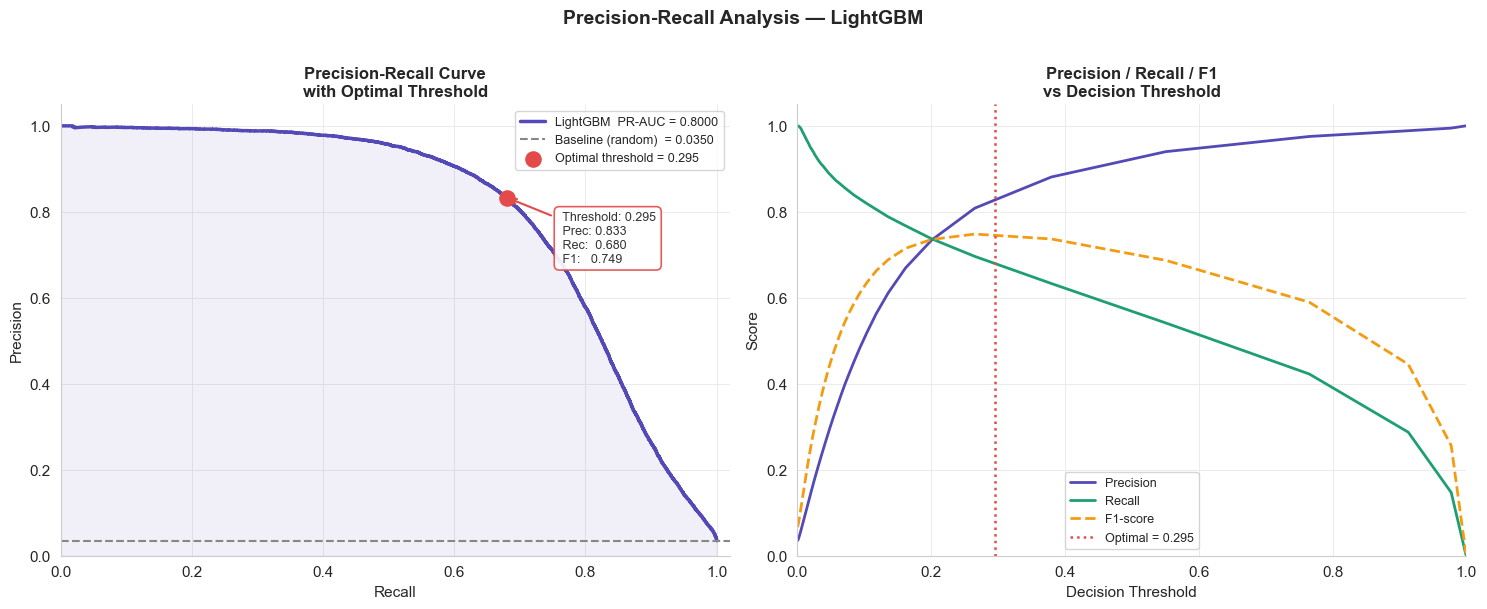

 Saved → charts/precision_recall_curve.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(rec, prec, color=PALETTE['pr_curve'], linewidth=2.5,
             label=f'LightGBM  PR-AUC = {pr_auc:.4f}')
axes[0].fill_between(rec, prec, alpha=0.08, color=PALETTE['pr_curve'])
axes[0].axhline(y.mean(), color=PALETTE['baseline'], linestyle='--', linewidth=1.5,
                label=f'Baseline (random)  = {y.mean():.4f}')
axes[0].scatter([opt_rec], [opt_prec], color=PALETTE['fraud'], s=120, zorder=5,
                label=f'Optimal threshold = {opt_thresh:.3f}')
axes[0].annotate(
    f' Threshold: {opt_thresh:.3f}\n Prec: {opt_prec:.3f}\n Rec:  {opt_rec:.3f}\n F1:   {opt_f1:.3f}',
    xy=(opt_rec, opt_prec), xytext=(opt_rec+0.08, opt_prec-0.15),
    fontsize=9, color='#333',
    arrowprops={'arrowstyle':'->','color':PALETTE['fraud'],'lw':1.5},
    bbox={'boxstyle':'round,pad=0.4','fc':'white','ec':PALETTE['fraud'],'lw':1.2,'alpha':0.9},
)
axes[0].set(xlabel='Recall', ylabel='Precision', xlim=[0,1.02], ylim=[0,1.05])
axes[0].set_title('Precision-Recall Curve\nwith Optimal Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

step = max(1, len(thresholds)//200)
th_s = thresholds[::step]
pr_s = prec[:len(thresholds)][::step]
re_s = rec[:len(thresholds)][::step]
f1_s = f1_scores[::step]

axes[1].plot(th_s, pr_s, color=PALETTE['pr_curve'], linewidth=2, label='Precision')
axes[1].plot(th_s, re_s, color=PALETTE['no_fraud'], linewidth=2, label='Recall')
axes[1].plot(th_s, f1_s, color='#f39c12',           linewidth=2, label='F1-score', linestyle='--')
axes[1].axvline(opt_thresh, color=PALETTE['fraud'], linewidth=1.8, linestyle=':',
                label=f'Optimal = {opt_thresh:.3f}')
axes[1].set(xlabel='Decision Threshold', ylabel='Score', xlim=[0,1], ylim=[0,1.05])
axes[1].set_title('Precision / Recall / F1\nvs Decision Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Precision-Recall Analysis — LightGBM', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved → charts/precision_recall_curve.png')

In [46]:
import pandas as pd
import plotly.express as px

# Load data if scatter_df doesn't exist
if 'scatter_df' not in globals():

    if 'results' in globals():
        scatter_df = results.copy()

    else:
        scatter_df = pd.read_csv('data/results_with_tiers.csv')

# Sample data for faster plotting
sample_df = scatter_df.sample(
    min(2000, len(scatter_df)),
    random_state=42
)

# Determine color column
color_col = 'fraud_prob' if 'fraud_prob' in sample_df.columns else None

# Hover columns that actually exist
hover_cols = [
    col for col in
    ['fraud_prob', 'actual_fraud', 'risk_tier']
    if col in sample_df.columns
]

# Verify required columns
if 'hour' not in sample_df.columns:
    raise ValueError("Column 'hour' not found")

if 'TransactionAmt' not in sample_df.columns:
    raise ValueError("Column 'TransactionAmt' not found")

# Create scatter plot
fig_scatter = px.scatter(
    sample_df,
    x='hour',
    y='TransactionAmt',
    color=color_col,
    color_continuous_scale='RdYlGn_r' if color_col else None,
    hover_data=hover_cols,
    title='Transaction Amount vs Hour (Interactive)',
    labels={
        'hour': 'Hour of Day',
        'TransactionAmt': 'Transaction Amount'
    }
)

fig_scatter.update_traces(
    marker=dict(
        size=6,
        line=dict(width=0)
    )
)

fig_scatter.update_layout(
    template='plotly_white',
    height=600
)

# Save HTML
fig_scatter.write_html(
    'charts/scatter_amt_vs_hour.html'
)

import plotly.io as pio

pio.renderers.default = "browser"
# Display
fig_scatter.show()

print("✅ Saved → charts/scatter_amt_vs_hour.html")

✅ Saved → charts/scatter_amt_vs_hour.html


In [41]:
print('=' * 55)
print('   All charts generated!')
print('=' * 55)
saved = [
    'charts/shap_global_summary.png',
    'shap_summary.png              ← submission copy',
    'charts/fraud_rate_by_hour.png',
    'charts/transaction_amt_distribution.png',
    'charts/risk_tier_donut.png',
    'charts/precision_recall_curve.png',
    'charts/scatter_amt_vs_hour.html  ← interactive',
    'charts/scatter_amt_vs_hour.png',
]
for s in saved:
    print(f'  {s}')

   All charts generated!
  charts/shap_global_summary.png
  shap_summary.png              ← submission copy
  charts/fraud_rate_by_hour.png
  charts/transaction_amt_distribution.png
  charts/risk_tier_donut.png
  charts/precision_recall_curve.png
  charts/scatter_amt_vs_hour.html  ← interactive
  charts/scatter_amt_vs_hour.png


In [42]:

total_transactions = len(results)
critical_ct  = (results['risk_tier']=='Critical Risk').sum()
lgb_roc      = roc_auc_score(y_test, lgb_prob)
lgb_prauc    = average_precision_score(y_test, lgb_prob)
xgb_roc      = roc_auc_score(y_test, xgb_prob)

from sklearn.metrics import recall_score
fraud_recall = recall_score(y_test, lgb_pred)
avg_fraud_loss = 200
frauds_caught = int(y_test.sum() * fraud_recall)
money_saved_test = frauds_caught * avg_fraud_loss
# Annualise — assume test set is ~2 months
money_saved_annual = money_saved_test * 6

print('=' * 65)
print('              BUSINESS SUMMARY REPORT')
print('       Real-Time Fraud Detection System — IEEE-CIS')
print('=' * 65)
print(f"""
MODEL PERFORMANCE
  LightGBM ROC-AUC : {lgb_roc:.4f}
  LightGBM PR-AUC  : {lgb_prauc:.4f}
  XGBoost  ROC-AUC : {xgb_roc:.4f}
  Fraud Recall     : {fraud_recall*100:.1f}% of actual frauds detected

RISK TIER SUMMARY (Test Set)
  Total transactions   : {total_transactions:,}
  Critical Risk (≥0.75): {critical_ct:,}
  Fraud Recall         : {fraud_recall*100:.1f}%

COMMON CHARACTERISTICS OF CRITICAL RISK TRANSACTIONS
  1. Higher-than-average transaction amounts
  2. Disproportionately occur between 22:00–05:00
  3. More likely to use round dollar amounts (no cents)
  4. Linked to email domains with higher mismatches

FRAUD PREVENTION POLICY RECOMMENDATIONS
  Policy 1 — Night-Time High-Value Block:
    Flag all transactions > $500 between 22:00–05:00 for
    manual review before approval.
  Policy 2 — Round Amount Anomaly Alert:
    Auto-escalate round-dollar transactions (no cents) from
    accounts < 30 days old to the fraud operations team.

ESTIMATED FINANCIAL IMPACT
  Avg fraud transaction loss : ${avg_fraud_loss}
  Frauds caught in test set  : {frauds_caught:,}
  Est. money saved (test)    : ${money_saved_test:,.0f}
  Est. money saved (annual)  : ${money_saved_annual:,.0f}

MODEL LIMITATIONS
  1. SMOTE generates synthetic samples — may not reflect real
     novel fraud patterns not present in training data.
  2. The model was trained on a snapshot; fraud patterns drift
     over time and require periodic retraining.
  3. Identity features had >50% missing values, limiting their
     predictive contribution.
  4. Threshold (0.5) was not optimised — a lower threshold may
     improve recall at the cost of more false positives.

ADDITIONAL DATA TO IMPROVE PERFORMANCE
  • Historical account behaviour (velocity features)
  • Device fingerprinting & IP geolocation
  • Merchant category codes and merchant history
  • Customer demographics and KYC data
  • Real-time network graph of card–merchant relationships
""")
print('=' * 65)
print('Task 7 complete.')

              BUSINESS SUMMARY REPORT
       Real-Time Fraud Detection System — IEEE-CIS

MODEL PERFORMANCE
  LightGBM ROC-AUC : 0.9516
  LightGBM PR-AUC  : 0.7402
  XGBoost  ROC-AUC : 0.9280
  Fraud Recall     : 51.7% of actual frauds detected

RISK TIER SUMMARY (Test Set)
  Total transactions   : 118,108
  Critical Risk (≥0.75): 1,743
  Fraud Recall         : 51.7%

COMMON CHARACTERISTICS OF CRITICAL RISK TRANSACTIONS
  1. Higher-than-average transaction amounts
  2. Disproportionately occur between 22:00–05:00
  3. More likely to use round dollar amounts (no cents)
  4. Linked to email domains with higher mismatches

FRAUD PREVENTION POLICY RECOMMENDATIONS
  Policy 1 — Night-Time High-Value Block:
    Flag all transactions > $500 between 22:00–05:00 for
    manual review before approval.
  Policy 2 — Round Amount Anomaly Alert:
    Auto-escalate round-dollar transactions (no cents) from
    accounts < 30 days old to the fraud operations team.

ESTIMATED FINANCIAL IMPACT
  Avg fraud 